## Анализ отзывов

В рамках данного кейса предлагается с помощью ИИ и машинного обучения поизучать отзывы людей на железнодорожные вокзалы Москвы. В рамках кейса предоставляются отзывы пользователей с Яндекс-карт, но возможно дополнительно использовать доступные в Интернет данные. 

Что ожидается в качестве результата:
* Инфографика, наглядно демонстрирующая полученные командой результаты
* Доклад, представляющий эти результаты
* Код в Jupyter Notebook с анализом данных

В данном ноутбуке показывается, как получить доступ к датасету, и первые шаги по его обработке с помощью доступных открытых моделей с HuggingFace, и с помощью YandexGPT. Можно использовать данный ноутбук как оправную точку для выполнения задания, расширив его дополнительными идеями, например:
* Кластеризация отзывов
* Обучение своих моделей для классификации тематики отзывов
* Использование предобученных NER-моделей
* Подробный анализ отзывов с помощью LLM

> В начале работы мы будем использовать модель с HuggingFace, поэтому работа будет быстрее, если вы будете запускать код на узле с поддержкой GPU

Для начала установим библиотеки:

In [2]:
%pip install transformers==4.49.0 openai torch==2.0.1

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 65.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 17.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 152.3 MB/s  0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.29.0
    Uninstalling huggingface_hub-1.29.0:━━━━━━━━ 0/3 [huggingface-hub]
      Successfully uninstalled huggingface_hub-1.29.00/3 [huggingface-hub]
  Attempting uninstall: tokenizers━━━━━━━━━━━━━━ 0/3 [huggingface-hub]
    Found existing installation: tokenizers 0.23.10/3 [huggingface-hub]
    Uninstalling tokenizers-0.23.1:━━━━━━━━━ 0/3 [huggingface-hub]
      Successfully uninstalled tokenizers-0.23.1 0/3 [huggingface-hub]
  Attempting uninstall: transformers━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [tokenizers]
    Found existing installation: transformers 5.16.1━━━━━━━━━━ 1/3 [tokenizers]
    Uninst

### Получение датасета

In [1]:
!wget https://storage.yandexcloud.net/mypub/data/rail_reviews.zip

--2026-09-02 23:20:48--  https://storage.yandexcloud.net/mypub/data/rail_reviews.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 390394 (381K) [application/x-zip-compressed]
Saving to: ‘rail_reviews.zip’

     0K .......... .......... .......... .......... .......... 13% 2.21M 0s
    50K .......... .......... .......... .......... .......... 26% 1.63M 0s
   100K .......... .......... .......... .......... .......... 39% 1.61M 0s
   150K .......... .......... .......... .......... .......... 52% 1.61M 0s
   200K .......... .......... .......... .......... .......... 65% 1.98M 0s
   250K .......... .......... .......... .......... .......... 78% 1.96M 0s
   300K .......... .......... .......... .......... .......... 91% 1.64M 0s
   350K .......... .......... .......... .                 

In [2]:
!unzip *.zip

Archive:  rail_reviews.zip
  inflating: reviews_Belorussky_railway_station.json  
  inflating: reviews_Kazan_Station.json  
  inflating: reviews_Kursky_station.json  
  inflating: reviews_Kyiv_railway_station.json  
  inflating: reviews_Paveletsky_railway_station.json  
  inflating: reviews_Rizhsky_railway_station.json  
  inflating: reviews_Savyolovsky_station.json  
  inflating: reviews_Vostochny_station.json  


### Преобразуем данные в DataFrame

Как видите, каждый вокзал представлен своим набором отзывов следующего вида:

In [1]:
import json
j = json.load(open('reviews_Belorussky_railway_station.json'))
j[0]

{'id': 1251,
 'dislike': 1,
 'like': 10,
 'review_text': 'Очень красивое место, вежливый персонал.\nЕздила на поезде из Москвы в Беларусь, комфортно, белье чистое, тепло, можно с животными. Дают горячий чай прям в постель, можно даже не переутруждаться, там о вВс и вашем комфорте позаботиться квалифицированные сотрудники.',
 'author': 'Александра Подгайская',
 'review_rating': 5,
 'datetime': '2024-01-12T16:53:33.611Z'}

Для удобства, сведём все отзывы в одну табличку. Для этого нам нужно будет добавить в каждое JSON-описание отзыва название вокзала.

In [2]:
import pandas as pd
import os
from glob import glob

res = []
for fn in glob('*.json'):
    j = json.load(open(fn))
    for x in j:
        x['station'] = fn.split('_')[1]
    res.extend(j)
    
df = pd.DataFrame(res)
df

,id,dislike,like,review_text,author,review_rating,datetime,station
0,1251,1,10,"Очень красивое место, вежливый персонал.\nЕзди...",Александра Подгайская,5,2024-01-12T16:53:33.611Z,Belorussky
1,1252,0,5,"Расположен очень удобное, строятся новые пути ...",Пользователь Э.,5,2023-11-10T21:33:56.176Z,Belorussky
2,1253,2,7,Очень уютный и удобный вокзал. Мне он очень нр...,Н И,5,2023-08-25T14:27:29.327Z,Belorussky
3,1254,1,5,"Красивое здание , очень удобно расположено в т...",Liliya Zugrova,5,2023-11-27T11:50:16.388Z,Belorussky
4,1255,2,7,С появление новых веток и маршрутов все стало ...,Татьяна Цымлова,5,2023-11-25T06:43:16.558Z,Belorussky
...,...,...,...,...,...,...,...,...
2264,2266,0,1,"Отличный вокзал. Новый, современный, прям из в...",Анна Елагина,5,2024-02-02T04:55:15.074Z,Vostochny
2265,2267,1,0,Бывал недавно там )) очень вкусная кухня \nКла...,Дмитрий,5,2023-11-12T14:21:47.541Z,Vostochny
2266,2268,0,0,Отличный и красивый вокзал. Чистые туалеты и б...,Валентина Архимановна,5,2024-01-31T10:53:36.364Z,Vostochny
2267,2269,3,10,"Это не вокзал , а скорее узловая станция или п...",Владислав Баранов,2,2023-12-06T12:03:14.107Z,Vostochny


Посмотрим на количество отзывов по вокзалам:

<Axes: xlabel='station'>

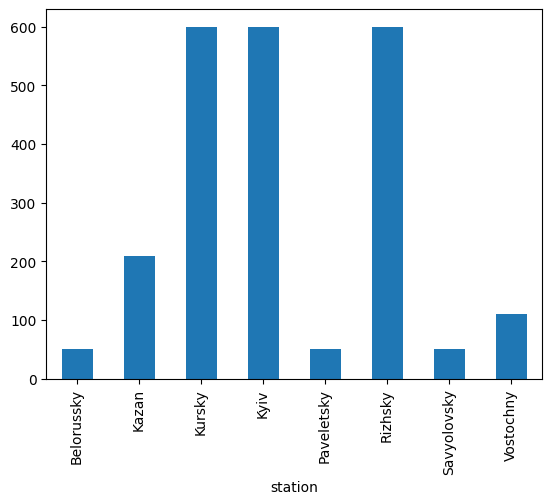

In [3]:
df.groupby('station')['review_text'].count().plot.bar()

### Обогащение данных с помощью модели с HuggingFace

Для обогащения данных можно использовать различные нейросетевые модели. Для начала, попробуем определить тональность текста.

Попробуем использовать модель [blanchefort/rubert-base-cased-sentiment-rurewiews](https://huggingface.co/blanchefort/rubert-base-cased-sentiment-rurewiews) с HuggingFace, натренированную на отзывах, с длиной 512 токенов. По умолчанию код из карточки модели выдает следующие классы:
* 0: NEUTRAL
* 1: POSITIVE
* 2: NEGATIVE

> Код не учитывает возможность работы на GPU, поэтому придётся внести в код несколько исправлений, чтобы можно было быстрее выполнять код на GPU.

In [4]:
import torch
from transformers import AutoModelForSequenceClassification
from transformers import BertTokenizerFast

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = BertTokenizerFast.from_pretrained('blanchefort/rubert-base-cased-sentiment-rurewiews')
model = AutoModelForSequenceClassification.from_pretrained('blanchefort/rubert-base-cased-sentiment-rurewiews', return_dict=True)
model.to(device)

@torch.no_grad()
def predict(text):
    inputs = tokenizer(text, max_length=512, padding=True, truncation=True, return_tensors='pt')
    inputs = inputs.to(device)
    outputs = model(**inputs)
    predicted = torch.nn.functional.softmax(outputs.logits, dim=1)
    predicted = torch.argmax(predicted, dim=1).cpu().numpy()
    return predicted


/home/jupyter/.local/lib/python3.10/site-packages/transformers/utils/hub.py:106: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
2026-09-02 23:30:33.958084: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-02 23:30:35.213173: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-02 23:30:39.543877: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Проверим, работает ли эта функция:

In [5]:
predict([
    'Ничего так вокзал, обычный...',
    'Обожаю этот вокзал, там такие симпатичные бомжи!',
    'Ненавижу это вокзал, поезда всегда опаздывают минимум на 20 минут'])

array([0, 1, 2])

Чтобы применить модель ко всему датасету, разобьем его на небольшие части, примерное по 200 отзывов, и предскажем тональность каждой из этих частей.

In [6]:
from tqdm.auto import tqdm
import numpy as np 

res = []
for d in tqdm(np.array_split(df,10)):
    z = list(d['review_text'])
    p = predict(z)
    res.extend(p)

100%|██████████| 10/10 [00:42<00:00,  4.26s/it]


Для удобства вставим колонку `sentiment` в датасет, но при этом изменим кодирование: будем представлять негативный отзыв цифрой -1.

In [7]:
df['sentiment'] = pd.Series(res).apply(lambda x: -1 if x==2 else x)

Запишем получившийся датасет на диск:

In [ ]:
df.to_csv('dataset_with_sentiment.csv',index=False)

Теперь можем посмотреть, какие вокзалы самые негативные или позитивные в Москве:

In [8]:
def count_pos(x):
    return x[x==1].count()
def count_neg(x):
    return x[x==-1].count()


df.groupby('station').agg({'sentiment' : ['mean', count_pos, count_neg ], 'review_text': 'count'})

sentiment                     review_text
                 mean count_pos count_neg       count
station                                              
Belorussky   0.680000        36         2          50
Kazan        0.647619       143         7         210
Kursky       0.395000       277        40         600
Kyiv         0.599332       385        26         599
Paveletsky   0.540000        27         0          50
Rizhsky      0.560000       374        38         600
Savyolovsky  0.480000        29         5          50
Vostochny    0.618182        71         3         110

В этом месте вы можете остановить виртуальную машину с GPU и перейти на более дешевый вариант **c1.4**

### Используем YandexGPT для извлечения смысла из отзывов

Попробуем использовать большую языковую модель для извлечения структурированной информации из текстов отзывов. Обратимся к LLM через [OpenAI-compatible Responses API](https://aistudio.yandex.ru/docs/en/ai-studio/) Yandex AI Studio.


Для работы с YandexGPT, нам потребуются значения `api_key` и `folder_id`. Их надо взять из секретов датасферы.

In [9]:
import os

folder_id = os.environ['folder_id']
api_key = os.environ['api_key']
print(f"Using folder {folder_id}")

Using folder b1gg3vl8onffhjb2nuct


Создадим функцию для вызова LLM-модели:

In [10]:
from openai import OpenAI

client = OpenAI(
    base_url="https://ai.api.cloud.yandex.net/v1",
    api_key=api_key,
    project=folder_id,
)
model = f"gpt://{folder_id}/deepseek-v4-flash"

def gpt(messages,
        system_message=None):
    if isinstance(messages,str):
        messages = [{ "role" : "user", "content" : messages }]
        if system_message is not None:
            messages.insert(0, { "role" : "system", "content" : system_message })
    response = client.responses.create(model=model, input=messages)
    return response.output_text

gpt("Расскажи анекдот про JSON и XML")


'Встречаются как-то JSON и XML в баре.\n\nXML подходит к бармену и говорит:\n— Будьте любезны, налейте мне `<напиток><тип>Крепкий</тип><название>Виски</название><предпочтение><лёд>Без</лёд></предпочтение></напиток>`.\n\nБармен смотрит на это, тяжело вздыхает и начинает листать спецификацию.\n\nТут подходит JSON:\n— А мне `{"тип": "Крепкий", "название": "Виски", "лёд": "Без"}`.\n\nБармен мгновенно наливает ему виски.\n\nXML возмущается:\n— Почему ему налили без вопросов, а мне приходится ждать?!\n\nБармен устало отвечает:\n— Потому что ты, мил человек, заполнил всю стойку открывающими и закрывающими тегами, а он просто сказал, что ему нужно, и закрыл вопрос. Так что пей уже и дай другим заказать!'

Для обработки, чтобы ускорить процесс демонстрации, выберем по 10 записей из каждого вокзала:

In [11]:
import pandas as pd

df = pd.read_csv('dataset_with_sentiment.csv')
df_sample = df.groupby('station').apply(lambda x: x.sample(10)).reset_index(drop=True)
df_sample

,id,dislike,like,review_text,author,review_rating,datetime,station,sentiment
0,1279,0,0,"Один из красивых вокзалов, г. Москвы, \nХороше...",Лекс,5,2023-11-04T12:49:54.572Z,Belorussky,1
1,1251,1,10,"Очень красивое место, вежливый персонал.\nЕзди...",Александра Подгайская,5,2024-01-12T16:53:33.611Z,Belorussky,1
2,1277,0,5,Мой любимый вокзал ❤️‍🔥 до дома доезжаю быстро...,Ирина Мартынова,5,2024-02-13T12:20:02.161Z,Belorussky,1
3,1288,1,8,Пришлось вчера побывать на белорусском вокзале...,Олег Тазбаш,2,2023-11-19T17:15:05.684Z,Belorussky,-1
4,1295,2,8,Белорусский вокзал – прекрасное место для нача...,Гном Чомски,5,2023-10-31T05:33:21.857Z,Belorussky,1
...,...,...,...,...,...,...,...,...,...
75,2229,2,3,"Хороший, современный вокзал. Достаточно частен...",Александр Баранов,5,2023-11-13T18:20:44.039Z,Vostochny,1
76,2182,0,0,"Вокзал конечно не в центре города, а в районе ...",Николай Бараненко,5,2023-12-09T05:49:33.192Z,Vostochny,0
77,2191,1,5,Очень удобно добираться до вокзала на метро и ...,Сергей Шевчук,5,2024-01-04T11:33:51.557Z,Vostochny,1
78,2237,0,4,"Видно, что вокзал делали с большой спешкой, ко...",Владислав Кошин,2,2023-12-05T15:56:28.646Z,Vostochny,-1


Попробуем выделить смысл из текста отзыва. Для примера выберем три аспекта отзывов: транспортная доступность вокзала, его чистота и точность хождения поездов. По каждому из этих аспектов попробуем выделить оценку, также в целом положительные и отрицательные моменты, и список тегов, о чем этот отзыв.

In [12]:
prompt = """
Прочитай следующий отзыв о вокзале в тройных обратных кавычках: ````{}```.
Из этого отзыва тебе необходимо выделить следующую информацию:
* sentiment - этот отзыв позитивный (positive), негативный (negative) или нейтральный (neutral)
* transport - транспортная доступность вокзала, по шкале 1..5, если об это говорится в отзыве. Если нет - 0
* cleanliness - чистота вокзала, по шкале 1..5, если об это говорится в отзыве. Если нет - 0
* schedule - точность хождения поездов, по шкале 1..5, если об это говорится в отзыве. Если нет - 0
* positive - краткий список позитивных моментов из отзыва
* negative - краткий список негативных моментов из отзыва
* tags - краткий список тегов, о чем этот отзыв, например: cleanliness, transport, trains
Результат необходимо вернуть в формате JSON такого вида:
{{
  "sentiment" : "...",
  "transport" : ...,
  "cleanliness" : ...,
  "schedule" : ...,
  "positive" : ["...", ...],
  "negative" : ["...", ...],
  "tags" : ["..."]
}}
"""

txt = df['review_text'].iloc[0]
print(txt)
res = gpt(prompt.format(txt))
res


Очень красивое место, вежливый персонал.
Ездила на поезде из Москвы в Беларусь, комфортно, белье чистое, тепло, можно с животными. Дают горячий чай прям в постель, можно даже не переутруждаться, там о вВс и вашем комфорте позаботиться квалифицированные сотрудники.


'{\n  "sentiment": "positive",\n  "transport": 0,\n  "cleanliness": 0,\n  "schedule": 0,\n  "positive": [\n    "Очень красивое место",\n    "Вежливый персонал",\n    "Комфортно в поезде",\n    "Чистое белье",\n    "Тепло",\n    "Можно с животными",\n    "Горячий чай подают в постель"\n  ],\n  "negative": [],\n  "tags": ["trains", "comfort", "animals"]\n}'

Чтобы гарантировать возврат ответа в формате JSON, используем так называемый structured output. Вместо того чтобы разбирать текст ответа, зададим модель данных на Python с помощью Pydantic: модель вернёт готовый объект с полями нужных типов.


In [13]:
from pydantic import BaseModel

class Review(BaseModel):
    sentiment: str
    transport: int
    cleanliness: int
    schedule: int
    positive: list[str]
    negative: list[str]
    tags: list[str]

txt = df['review_text'].iloc[0]
print(txt)
review = client.responses.parse(
    model=model,
    input=prompt.format(txt),
    text_format=Review,
).output_parsed
review


Очень красивое место, вежливый персонал.
Ездила на поезде из Москвы в Беларусь, комфортно, белье чистое, тепло, можно с животными. Дают горячий чай прям в постель, можно даже не переутруждаться, там о вВс и вашем комфорте позаботиться квалифицированные сотрудники.


Review(sentiment='positive', transport=0, cleanliness=0, schedule=0, positive=['красивое место', 'вежливый персонал', 'комфортно в поезде', 'чистое белье', 'тепло', 'можно с животными', 'горячий чай в постель'], negative=[], tags=['comfort', 'service', 'animals', 'train'])

Сохраним колонку `sentiment`, распознанную моделью HuggingFace.

In [14]:
pmap = { -1 : 'negative', 0 : 'neutral', 1 : 'positive' }
df_sample['hf_sentiment'] = df_sample['sentiment'].apply(lambda x: pmap[x])
df_sample.drop(columns=['sentiment'],inplace=True)

Теперь пройдёмся по всем строкам таблицы и извлечём информацию с помощью LLM. Для начала добавим новые пустые поля в таблицу, для хранения извлечённых значений:

In [15]:
import numpy as np

for f in ["sentiment","transport","cleanliness", "schedule", "positive", "negative", "tags"]:
    df_sample[f]=np.nan

Теперь собственно займёмся извлечением. Structured output возвращает сразу объект `Review` нужного типа, поэтому разбирать JSON вручную не нужно. Если отзыв уже распознан (поле `positive` заполнено), пропускаем его.


In [16]:
from tqdm.auto import tqdm

for i,r in tqdm(df_sample.iterrows(),total=len(df_sample)):
    txt = r['review_text']
    if not pd.isnull(r['positive']):
        continue # уже распознано
    review = client.responses.parse(
        model=model,
        input=prompt.format(txt),
        text_format=Review,
    ).output_parsed
    df_sample.at[i,'sentiment'] = review.sentiment
    df_sample.at[i,'transport'] = review.transport
    df_sample.at[i,'cleanliness'] = review.cleanliness
    df_sample.at[i,'schedule'] = review.schedule
    df_sample.at[i,'positive'] = ','.join(review.positive)
    df_sample.at[i,'negative'] = ','.join(review.negative)
    df_sample.at[i,'tags'] = ','.join(review.tags)


100%|██████████| 80/80 [08:08<00:00,  6.11s/it]


Посмотрим на результат:

In [ ]:
df_sample.to_csv('dataset_sample_with_GPT.csv',index=False)

In [ ]:
df_sample = pd.read_csv('dataset_sample_with_GPT.csv')
df_sample

## Делаем выводы и строим инфографику 

Посмотрим, насколько совпадают предсказания sentiment между YandexGPT и моделью с HuggingFace:

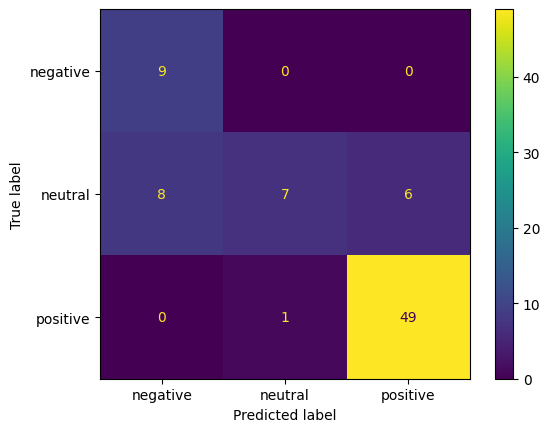

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(df_sample['hf_sentiment'],df_sample['sentiment'])

Посмотрим на средние значения показателей по всем вокзалам. Для этого сначала заменим нулевые значения на NaN, и затем осуществим аггрегацию:

In [18]:
for f in ["transport","cleanliness", "schedule"]:
    df_sample[f] = df_sample[f].apply(lambda x: np.nan if x==0 else x)

df_sample.groupby('station').agg( {'transport' : 'mean', 'cleanliness' : 'mean', 'schedule' : 'mean'})

,transport,cleanliness,schedule
station,,,
Belorussky,5.000000,5.00,NaN
Kazan,4.666667,3.00,NaN
Kursky,3.200000,5.00,3.0
Kyiv,5.000000,4.75,NaN
Paveletsky,5.000000,3.00,NaN
Rizhsky,NaN,5.00,NaN
Savyolovsky,5.000000,4.25,1.0
Vostochny,3.833333,4.75,NaN


Такую же информацию можно представить в виде графика:

<Axes: xlabel='station'>

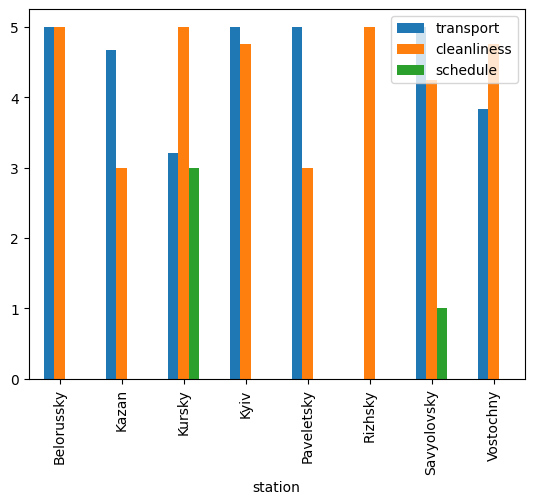

In [19]:
df_sample.groupby('station').agg(
    {'transport' : 'mean', 
     'cleanliness' : 'mean', 
     'schedule' : 'mean'}).plot.bar()

Теперь научимся извлекать интересующие нас отзывы по тегам. Для этого посмотрим на список всех тегов:

In [20]:
tags = list(df_sample['tags'].apply(lambda x: str(x).split(',')))
tags = set(sum(tags,[])) - { 'nan', '' }
tags

{'access',
 'accessibility',
 'aeroexpress',
 'amenities',
 'architecture',
 'atmosphere',
 'cafe',
 'cafes',
 'calm',
 'chapel',
 'cleanliness',
 'comfort',
 'construction',
 'convenience',
 'crowd',
 'crowding',
 'entrance',
 'facilities',
 'fine',
 'food',
 'history',
 'hotel',
 'information',
 'infrastructure',
 'interior',
 'leakage',
 'location',
 'logistics',
 'luggage storage',
 'modern',
 'museum',
 'navigation',
 'nostalgia',
 'organization',
 'overall',
 'parking',
 'passenger flow',
 'payment',
 'personnel',
 'pet-friendly',
 'platform',
 'quality',
 'renovation',
 'repair',
 'restroom',
 'safety',
 'scenery',
 'schedule',
 'seating',
 'security',
 'service',
 'services',
 'shops',
 'signage',
 'signs',
 'smoking',
 'square',
 'staff',
 'station',
 'surroundings',
 'terminal',
 'ticket buying',
 'tickets',
 'toilet',
 'toilets',
 'train',
 'trains',
 'transport',
 'user experience',
 'ventilation',
 'waiting area',
 'wifi',
 'архитектура',
 'атмосфера',
 'атрибутика',
 'вне

Опишем функцию `tag_lookup`, которая будет возвращать фрагмент таблицы, в который входит интересующий нас тег:

In [21]:
def tag_lookup(tag):
    return df_sample[df_sample['tags'].apply(lambda x: tag in str(x))]

tag_lookup('food')[['station','review_text']]

,station,review_text
14,Kazan,Культовое место) Приятный фастфуд и веселые но...
31,Kyiv,"Удобно,красиво,старинное здание с перроном,сам..."
61,Savyolovsky,Ничего особенного. На вокзале можно подождать ...


Посмотрим, на каком вокзале есть музей:

In [22]:
tag_lookup('museum')[['station','review_text']]

,station,review_text
56,Rizhsky,Здание вокзала чистое и очень красивое. Просто...


## Подведение итогов

Зададимся задачей подытожить все положительные и отрицательные моменты для каждого из вокзалов. Сначала объединим все значения колонок `positive` и `negative` для каждого из вокзалов:

In [23]:
join = lambda x : ', '.join([t for t in x if isinstance(t,str) and len(t)>0])

df_stations = df_sample.groupby('station').agg({ 'positive' : join, 'negative' : join }).reset_index()
df_stations

,station,positive,negative
0,Belorussky,"Хорошее расположение,Удобно добраться на метро...",нужно внимательно заранее построить маршрут пр...
1,Kazan,"великолепная архитектура,впечатляющие конструк...","не везде убрано, проблемы с парковкой,неудобны..."
2,Kursky,"Вокзал меняется, удобное расположение,поезда п...","Для пожилых людей нет удобств,К электричке над..."
3,Kyiv,"Удобная камера хранения,Разумная цена,Возможно...",Пункты питания представлены только фастфудом и...
4,Paveletsky,"Удобный выход с метро и с улицы,Рядом хорошие ...",станция и платформы пригородных поездов требую...
5,Rizhsky,"Спокойно,Уютно,Быстро можно купить билеты,Поря...","Стройка доставляет неудобства,Реконструкция пр..."
6,Savyolovsky,"можно подождать электричку,бесплатный туалет,е...","На станции Новодачная не было турникетов, толь..."
7,Vostochny,"Лифт позволяет добраться до любого этажа,Эскал...","带行李需走楼梯，坡道不方便,对轮椅用户不友好, Далековато от центра, ..."


Теперь применим большую языковую модель для того, чтобы суммаризировать все факты в один конкретный текст:

In [24]:
prompt_sum = """
Пожалуйста, прочитай список отзывов о вокзале ниже в тройных обратных кавычках и запиши краткое содержание
всего прочитанного текста в виде нескольких абзацев текста. Отзывы: ```{}```
"""

def summarize(x):
    res = gpt(prompt_sum.format(x))
    return res

df_stations['pos_summary'] = df_stations['positive'].apply(summarize)
df_stations['neg_summary'] = df_stations['negative'].apply(summarize)

In [25]:
from IPython.display import display
with pd.option_context('display.max_colwidth', 0):
    display(df_stations[['station','pos_summary','neg_summary']])

,station,pos_summary,neg_summary
0,Belorussky,"Прочитанные отзывы в целом рисуют образ современного, удобного и гостеприимного вокзала, который высоко ценится пассажирами за свою транспортную доступность. Отмечается удачное расположение с близостью сразу двух станций метро, хороший подъезд для автомобилей, большая парковка и развитая сеть общественного транспорта. Это позволяет быстро добраться до вокзала и легко уехать в любом направлении.\n\nИнфраструктура вокзала также заслуживает исключительно положительных оценок. Пассажиры хвалят красивое и современное здание в приятных «мятных» тонах, просторные и чистые залы ожидания, а также широкий спектр сопутствующих услуг: множество магазинов, кафе, информационных центров, прокат автомобилей и большое количество банкоматов. Удобная организация билетных касс и автоматов также упоминается как значительный плюс.\n\nОсобо подчеркивается высокий уровень сервиса и заботы о клиентах. Отзывы отмечают вежливый, отзывчивый и готовый помочь персонал, создающий атмосферу гостеприимства. Комфорт поездки дополняется такими деталями, как чистое белье, тепло в помещении, возможность провезти животных и даже подача горячего чая в постель, что указывает на внимательное отношение к деталям (предположительно, в капсульных отелях или поездах дальнего следования). Также упоминается возможность быстрой пересадки на скоростные поезда («Ласточка») со временем в пути около 5 часов.\n\nНаконец, вокзал воспринимается не просто как транзитный пункт, но как значимое историческое место, вызывающее теплые эмоции и связанное с историей города и личными воспоминаниями людей. Несмотря на любовь к старому облику, пользователи положительно оценивают гармоничное обновление здания и выражают надежду на то, что этот вокзал превратится в настоящую «транспортную жемчужину», сохранив свой уникальный характер.","На основе предоставленных отзывов можно сделать следующие выводы.\n\nВокзал в настоящее время находится в состоянии длительной реконструкции или благоустройства, что создает значительные неудобства для пассажиров. Строительные работы продолжаются даже после заявленного срока окончания, а из-за недостаточного количества обустроенных подходов и проходов посетителям приходится передвигаться по грязи.\n\nСуществуют серьезные проблемы с навигацией и информированием: пассажирам сложно найти нужные входы, выходы и остановки, а также не хватает указателей. Это требует от посетителей заранее и очень тщательно планировать маршрут, чтобы не потеряться.\n\nКроме того, наблюдаются технические и сервисные сбои: не работает оплата по SMS, отсутствует пункт оплаты, а служба поддержки не отвечает на обращения. Это создает риск получения необоснованных штрафов (например, на 5 тысяч рублей). Также отмечаются ограничения на фотосъемку.\n\nНесмотря на негативные стороны, в отзывах содержится практический совет: внимательно изучать схему проезда и расположение объектов до прибытия, чтобы минимизировать неудобства, связанные с текущей ситуацией."
1,Kazan,"На основе предоставленных отзывов можно составить следующее краткое содержание.\n\nВокзал производит сильное впечатление благодаря своей **великолепной и красивой архитектуре**, впечатляющим конструкциям и особой атмосфере, пропитанной историей. Многие посетители называют его культовым местом, отмечая, что он является не просто транспортным узлом, но и достопримечательностью.\n\nПрактическая сторона также оценивается очень высоко. Отмечается **удобное расположение** как в городе (легко добраться на общественном транспорте, рядом выходы из метро), так и с точки зрения логистики (недалеко до аэропорта). Вокзал предлагает множество направлений, включая электрички, что делает его важным хабом.\n\nВнутренняя инфраструктура продумана для комфорта пассажиров. Здесь есть **уютные залы ожидания**, множество магазинов, точек быстрого питания, павильонов, сувенирных лавок и даже аптека. Посетители хвалят наличие общепита и приятный фастфуд, а также отмечают веселых носильщиков.\n\nНаконец, особо по

## Заключение

Yandex Cloud позволяет вам как использовать ресурсы с GPU для запуска готовых предобученных моделей, так и предоставляет готовые сервисы и фундаментальные модели, которые можно использовать для решения ваших задач. Хотя мы это не показали, ресурсы GPU можно использовать и для обучения моделей!